# Default of Credit Card Clients Dataset

### **Instances** 30000
### **Features** 23

This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
- **X1:** Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
- **X2:** Gender (1 = male; 2 = female).
- **X3:** Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
- **X4:** Marital status (1 = married; 2 = single; 3 = others).
- **X5:** Age (year).
- **X6 - X11:** History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
- **X12 - X17:** Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.
- **X18 - X23:** Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [2]:
%pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
x = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

In [4]:
# metadata
print(default_of_credit_card_clients.metadata)

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [5]:
# variable information
print(default_of_credit_card_clients.variables)

   name     role     type      demographic                 description units  \
0    ID       ID  Integer             None                        None  None   
1    X1  Feature  Integer             None                   LIMIT_BAL  None   
2    X2  Feature  Integer              Sex                         SEX  None   
3    X3  Feature  Integer  Education Level                   EDUCATION  None   
4    X4  Feature  Integer   Marital Status                    MARRIAGE  None   
5    X5  Feature  Integer              Age                         AGE  None   
6    X6  Feature  Integer             None                       PAY_0  None   
7    X7  Feature  Integer             None                       PAY_2  None   
8    X8  Feature  Integer             None                       PAY_3  None   
9    X9  Feature  Integer             None                       PAY_4  None   
10  X10  Feature  Integer             None                       PAY_5  None   
11  X11  Feature  Integer             No

In [6]:
df = pd.concat([x, y], axis=1)
df.head(10)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,50000,1,1,2,37,0,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,500000,1,1,2,29,0,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,100000,2,2,2,23,0,-1,-1,0,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,140000,2,3,1,28,0,0,2,0,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,20000,1,3,2,35,-2,-2,-2,-2,-1,...,0,13007,13912,0,0,0,13007,1122,0,0


In [7]:
# Check the shape of the dataset
print(f"Dataset shape: {df.shape}")

Dataset shape: (30000, 24)


In [8]:
for column in df.columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- X1 ---
X1
50000      3365
20000      1976
30000      1610
80000      1567
200000     1528
           ... 
800000        2
1000000       1
327680        1
760000        1
690000        1
Name: count, Length: 81, dtype: int64

--- X2 ---
X2
2    18112
1    11888
Name: count, dtype: int64

--- X3 ---
X3
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

--- X4 ---
X4
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

--- X5 ---
X5
29    1605
27    1477
28    1409
30    1395
26    1256
31    1217
25    1186
34    1162
32    1158
33    1146
24    1127
35    1113
36    1108
37    1041
39     954
38     944
23     931
40     870
41     824
42     794
44     700
43     670
45     617
46     570
22     560
47     501
48     466
49     452
50     411
51     340
53     325
52     304
54     247
55     209
56     178
57     122
58     122
59      83
21      67
60      67
61      56
62      44
64      31
63      31
66    

# Data Preprocessing

In [9]:
# Rename columns for better understanding
column_names = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6',
    'Y': 'DEFAULT'
}

df = df.rename(columns=column_names)

In [10]:
# --- Data Corrections ---
# 1. EDUCATION: According to documentation: 1 = graduate school; 2 = university; 3 = high school; 4 = others
# However, we see some values outside this range (0,5,6) which we'll treat as "others"
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})

# 2. MARRIAGE: According to documentation: 1 = married; 2 = single; 3 = others
# We see some 0 values which we'll treat as "others"
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})

# 4. BILL AMOUNTS: Some bill amounts might be negative, which doesn't make sense.
# We'll treat them as data entry errors and convert to positive:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df[bill_cols] = df[bill_cols].abs()


# Data Cleaning

In [11]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 35


In [12]:
# Remove duplicates (keeping first occurrence)
df = df.drop_duplicates()

In [13]:
# Verify removal
print(f"Remaining duplicates: {df.duplicated().sum()}")
print(f"New dataset shape: {df.shape}")

Remaining duplicates: 0
New dataset shape: (29965, 24)


In [14]:
# Summary statistics for numerical variables
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
            'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
            'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

print(df[num_cols].describe())

            LIMIT_BAL           AGE      BILL_AMT1      BILL_AMT2  \
count    29965.000000  29965.000000   29965.000000   29965.000000   
mean    167442.005006     35.487969   51328.484832   49291.316135   
std     129760.135222      9.219459   73626.449392   71157.533368   
min      10000.000000     21.000000       0.000000       0.000000   
25%      50000.000000     28.000000    3627.000000    3095.000000   
50%     140000.000000     34.000000   22443.000000   21351.000000   
75%     240000.000000     41.000000   67270.000000   64128.000000   
max    1000000.000000     79.000000  964511.000000  983931.000000   

          BILL_AMT3      BILL_AMT4      BILL_AMT5      BILL_AMT6  \
count  2.996500e+04   29965.000000   29965.000000   29965.000000   
mean   4.713202e+04   43386.821558   40429.800033   39058.193726   
std    6.932781e+04   64303.987903   60769.643808   59481.678352   
min    0.000000e+00       0.000000       0.000000       0.000000   
25%    2.809000e+03    2404.000000    

In [15]:
print("\nData types:")
print(df.dtypes)


Data types:
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
DEFAULT      int64
dtype: object


# Exploratory Data Analysis (EDA)

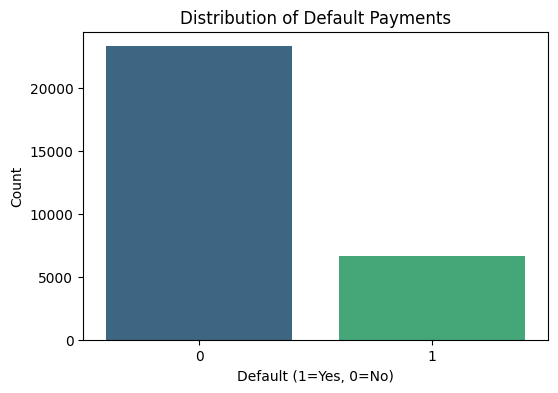

In [16]:
# Target distribution analysis
plt.figure(figsize=(6, 4))
sns.countplot(x='DEFAULT', data=df, palette='viridis')
plt.title('Distribution of Default Payments')
plt.xlabel('Default (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

In [17]:
df['DEFAULT'].value_counts()

,count
DEFAULT,
0,23335
1,6630


The dataset has a class imbalance, with more non-defaulters than defaulters

In [18]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']
X_train, X_test, y_train, y_test = train_test_split(df.drop('DEFAULT', axis=1), df['DEFAULT'], test_size=0.3, random_state=42)

In [19]:
from imblearn.over_sampling import SMOTE

# Define SMOTE and the model
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

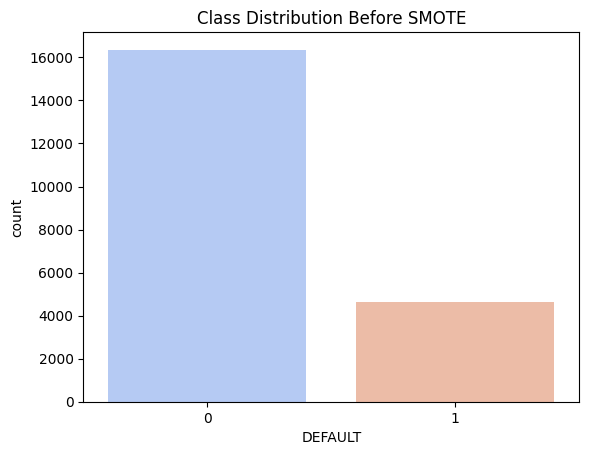

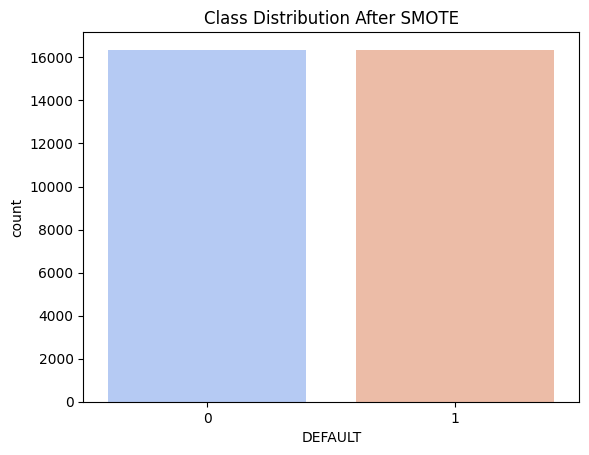

In [20]:
sns.countplot(x=y_train, palette="coolwarm")
plt.title("Class Distribution Before SMOTE")
plt.show()

sns.countplot(x=y_train_balanced, palette="coolwarm")
plt.title("Class Distribution After SMOTE")
plt.show()

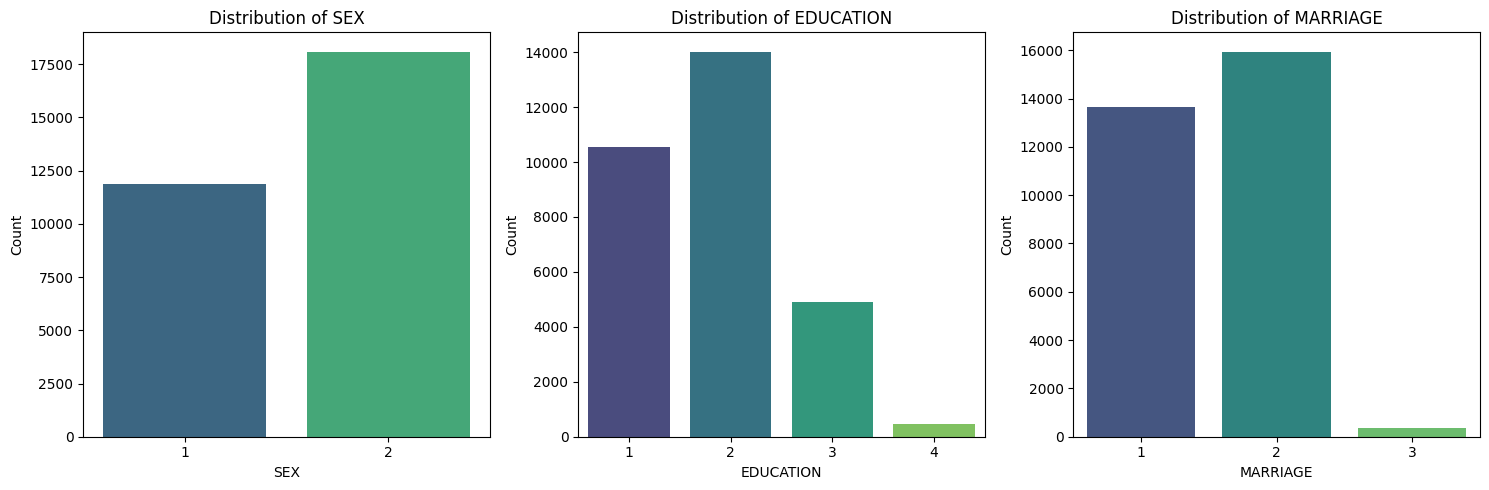

In [21]:
# Categorical features analysis
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

Exploring Demographics:

- SEX: The dataset contains more females than males.

- EDUCATION: Most individuals are either university graduates or high school graduates.

- MARRIAGE: Most individuals are either married or single.

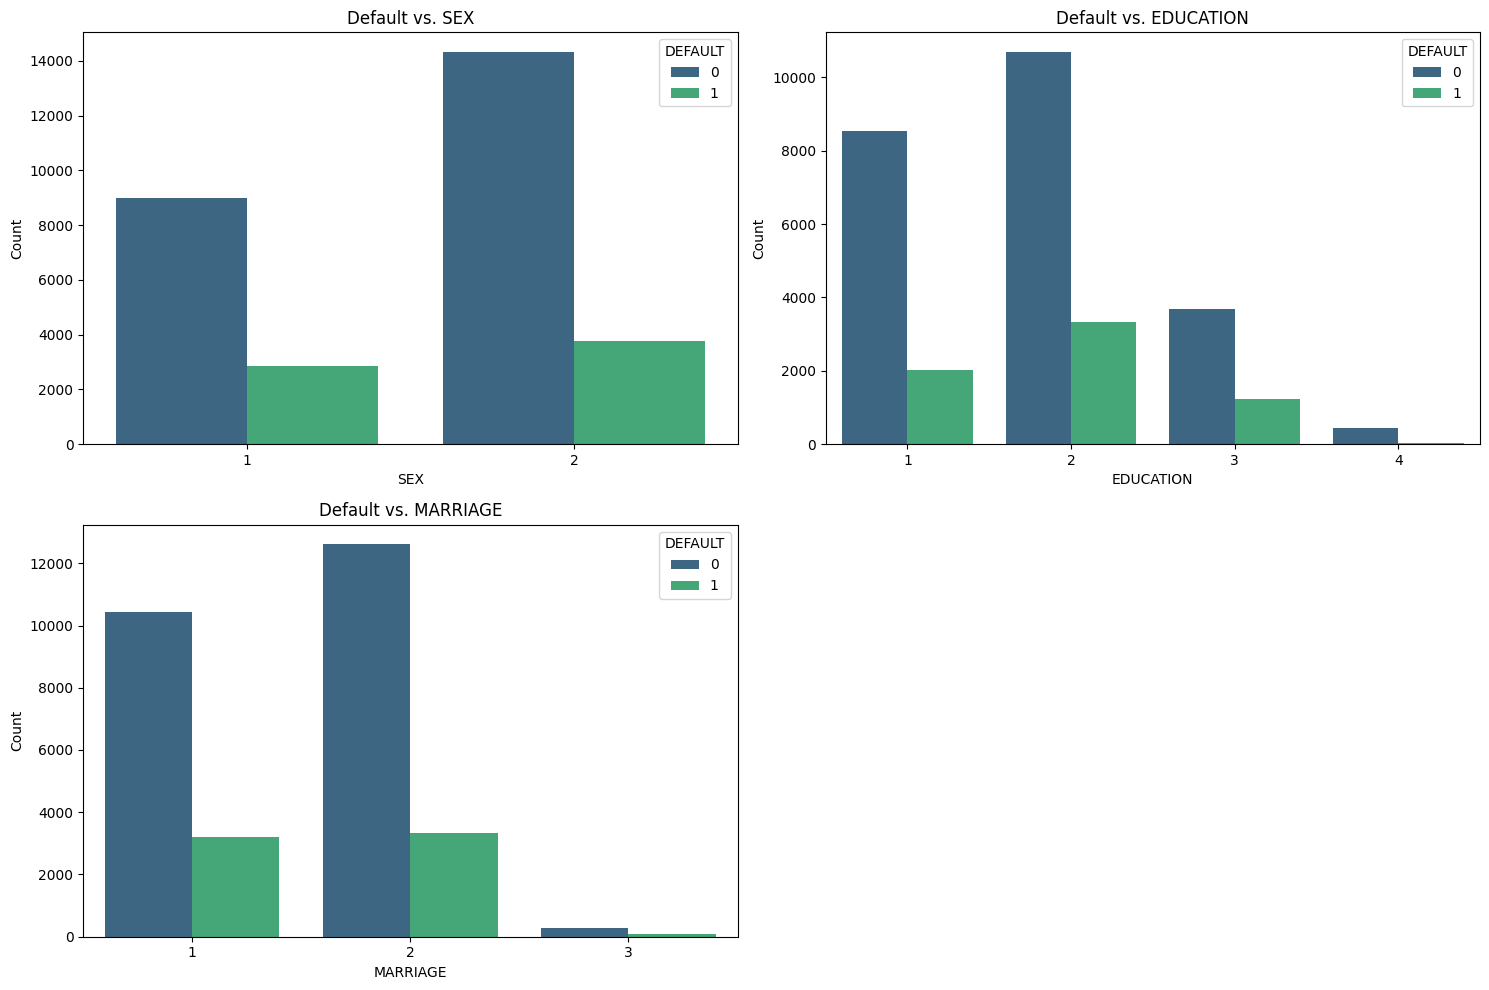

In [22]:
# Relationship between Categorical Features and Default
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, hue='DEFAULT', data=df, palette='viridis')
    plt.title(f'Default vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

Default rates vary across different categories of education, marital status, and gender.

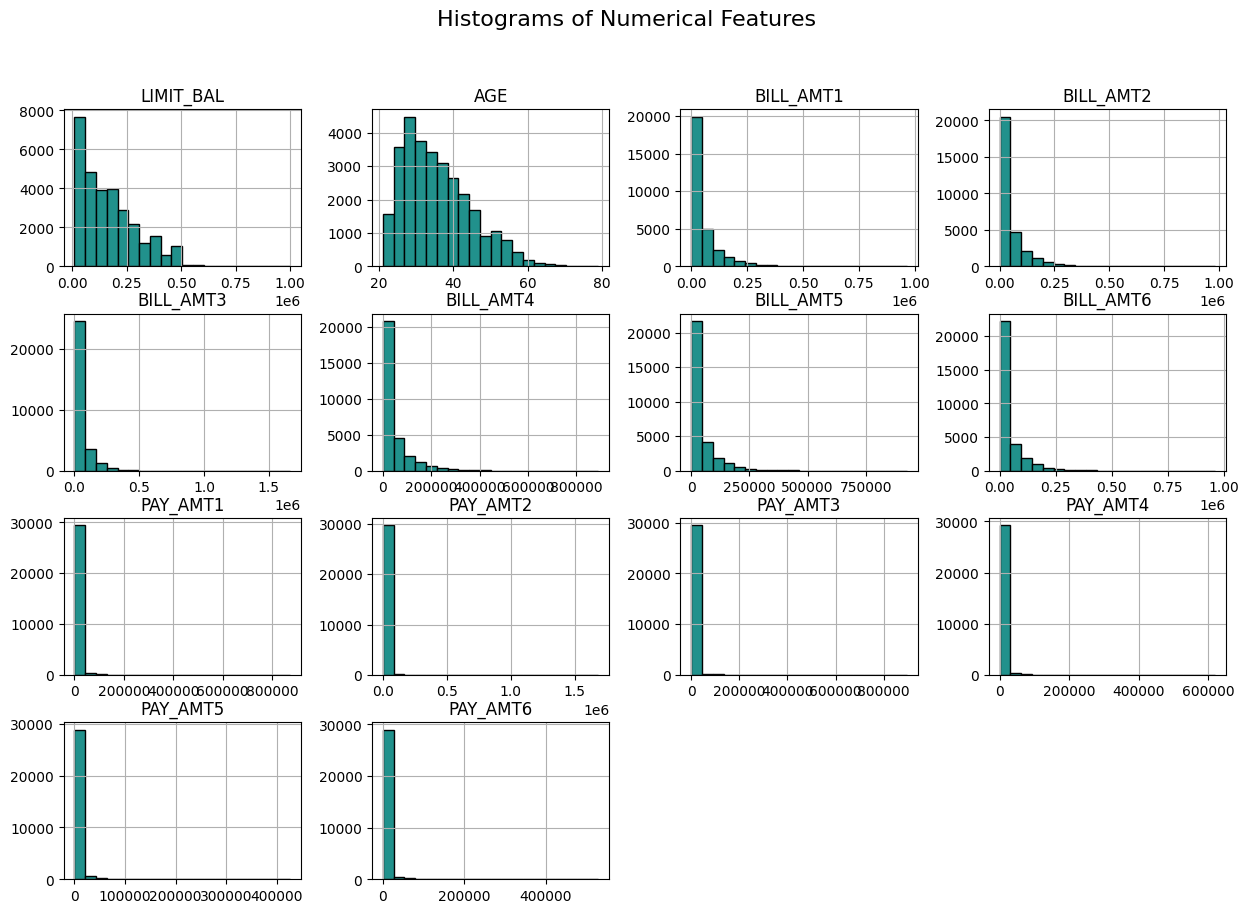

In [23]:
# Numerical features analysis
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df_numerical = df[numerical_features]

# Plot histograms of all numerical features
df_numerical.hist(figsize=(15, 10), bins=20, color='#21918c', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

Insights into features:

- LIMIT_BAL is right-skewed, indicating that most individuals have lower credit limits.
- AGE has a relatively normal distribution.
- Bill amounts and payment amounts are highly skewed, with a large number of smaller values and a few very large ones.

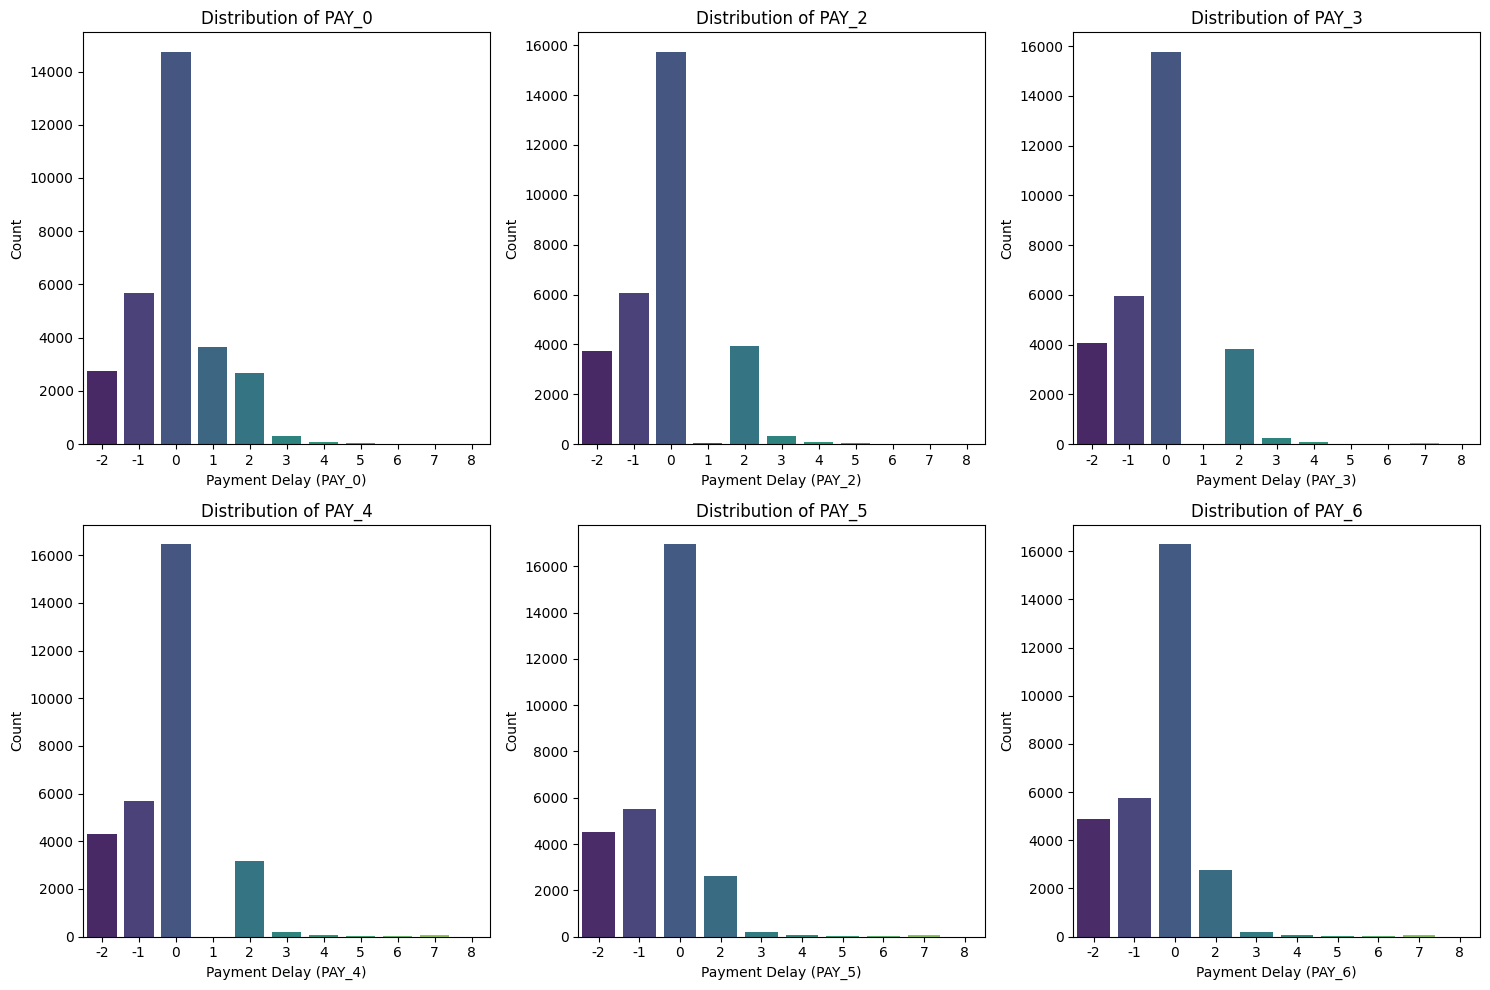

In [24]:
# Payment history analysis
pay_history_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

plt.figure(figsize=(15, 10))
for i, col in enumerate(pay_history_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'Payment Delay ({col})')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most customers have a history of paying on time

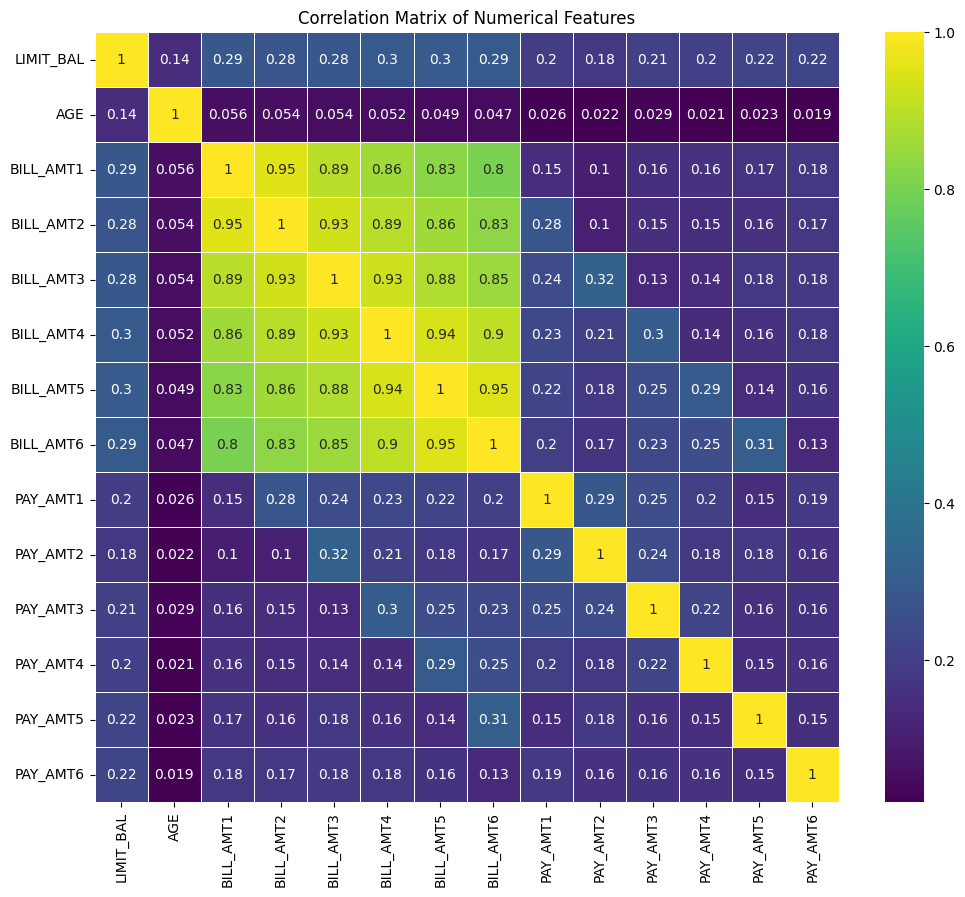

In [25]:
# Correlation analysis
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Correlations:
- The bill amounts from one month to the next are highly related.
- The payment amounts across different months also show positive relationships, though not as strong as with the bill amounts.
- There isn't a strong linear relationship between the outstanding bill amounts and the amounts paid.
- Credit limit has a weak positive association with bill amounts.
- Age appears to be largely independent of the other numerical features in terms of linear relationships.

# Outliers Handeling

In [26]:
# Step 1: Detect and flag outliers using IQR
outlier_flags = pd.DataFrame(index=df.index)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))
    outlier_flags[f'{col}_OUTLIER'] = outlier_mask.astype(int)

# Count how many outlier features each row has
df['TOTAL_OUTLIER_COUNT'] = outlier_flags.sum(axis=1)

In [27]:
# How many rows have at least one outlier?
print("Rows with at least one outlier:", (df['TOTAL_OUTLIER_COUNT'] > 0).sum())
# Outlier count per feature
outlier_flags.sum().sort_values(ascending=False)

Rows with at least one outlier: 10454


,0
PAY_AMT4_OUTLIER,2993
PAY_AMT6_OUTLIER,2960
PAY_AMT5_OUTLIER,2944
PAY_AMT1_OUTLIER,2742
BILL_AMT5_OUTLIER,2725
PAY_AMT2_OUTLIER,2723
BILL_AMT6_OUTLIER,2690
BILL_AMT4_OUTLIER,2615
PAY_AMT3_OUTLIER,2596
BILL_AMT3_OUTLIER,2469







*   Most outliers are concentrated in: PAY_AMT columns (payment amounts)
 & BILL_AMT columns (bill amounts)

*   Only a few in AGE and LIMIT_BAL, which is expected due to their more naturally distributed nature



# Features Standardization

In [28]:
# # Select numeric columns to standardize
# standardize_cols = num_cols
# scaler = StandardScaler()
# scaled_features = scaler.fit_transform(df[standardize_cols])

# # Create standardized DataFrame
# scaled_df = pd.DataFrame(scaled_features, columns=[f'{col}_SCALED' for col in standardize_cols], index=df.index)

# # Combine with original data
# df = pd.concat([df, scaled_df], axis=1)

# print(df.head())

# Dimensionality Reduction (PCA Algorithm)

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# All features
original_features = X.columns.tolist()
print(f"Original number of features: {len(original_features)}")


# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Analyze PCA results
print(f"Number of components after PCA: {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")
print(f"Number of features reduced: {len(original_features) - pca.n_components_}")

Original number of features: 23
Number of components after PCA: 15
Explained variance ratio: 0.96
Number of features reduced: 8


In [30]:
# PCA model Accuracy
model = RandomForestClassifier(random_state=42)
model.fit(X_train_pca, y_train_balanced.values.ravel())
y_pred_pca = model.predict(X_test_pca)
print("PCA Accuracy:", (round(accuracy_score(y_test, y_pred_pca),3)*100),"%")

PCA Accuracy: 75.9 %


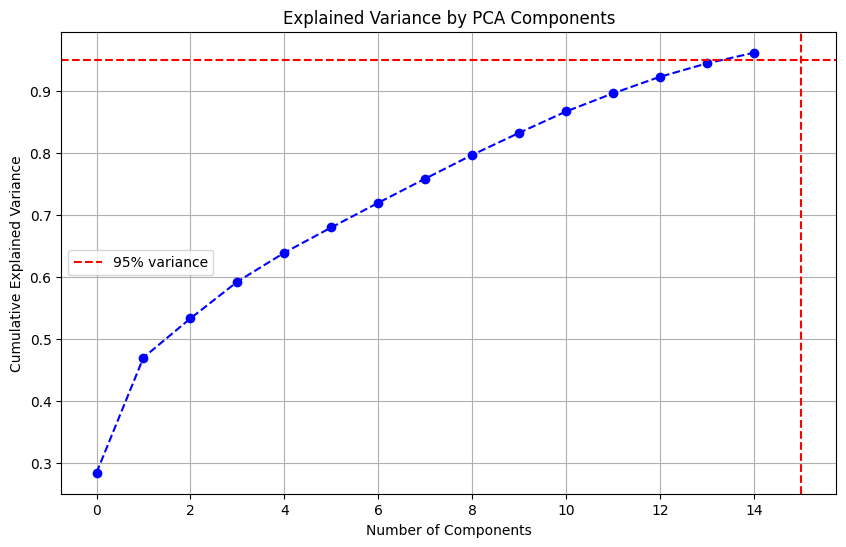

In [31]:
# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95)+1,
            color='r', linestyle='--')
plt.legend()
plt.show()

## **Interpretation of figure**

why although the 14 components exceed the 95% score we don't stop at ?

**line code** -> "np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1"

- np.cumsum(...) >= 0.95 returns a Boolean array.

- np.argmax(...) gives the index of the first True (i.e., when 95% is first
  reached or passed).

- +1 is added to convert from 0-based indexing to 1-based component numbering

**Therefore**

If the 15th component (index 13) just slightly falls short of 95%, the 16th one (index 14) is the first to cross 95%.

Even if the 14 components together look close enough, numerically, they may sum to just under 0.95 (e.g., 0.9499), so the algorithm goes to the next one.

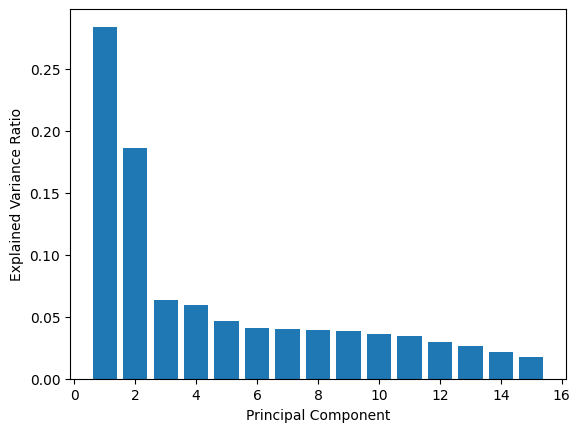

In [32]:
plt.bar(range(1, 16), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

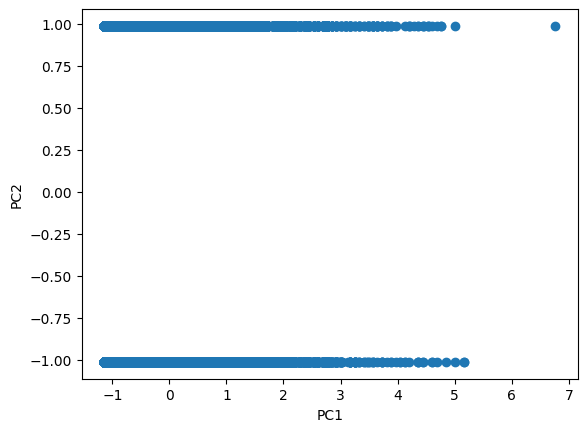

In [33]:
# Visualize components
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [34]:
transformed_data = pca.fit_transform(X_train_scaled)
df_pca = pd.DataFrame(transformed_data, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

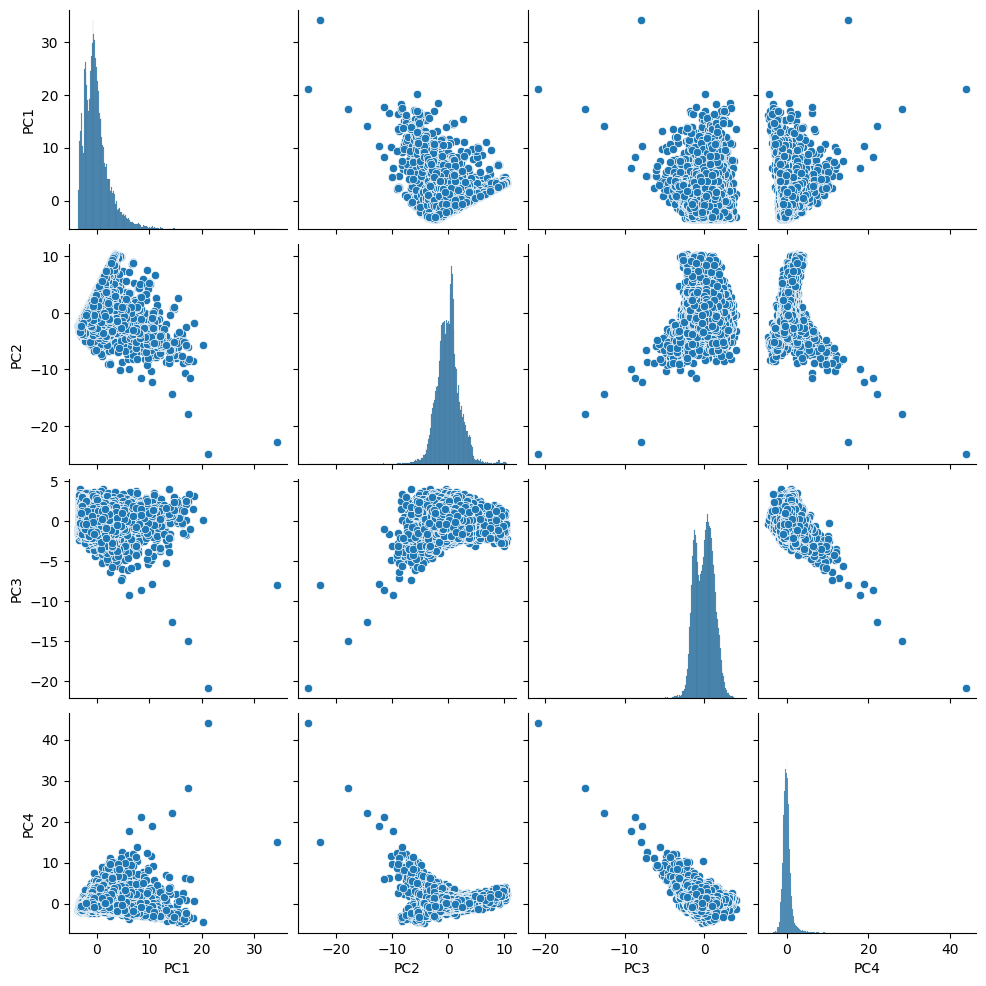

In [35]:
import seaborn as sns

# Create a DataFrame with all 16 components
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(15)])

# Plot pairwise relationships (first 4 components)
sns.pairplot(df_pca[['PC1', 'PC2', 'PC3', 'PC4']])
plt.show()

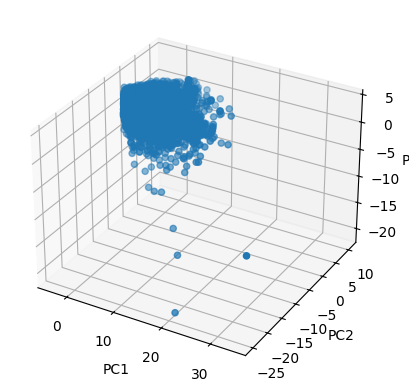

In [36]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_pca['PC1'], df_pca['PC2'], df_pca['PC3'])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

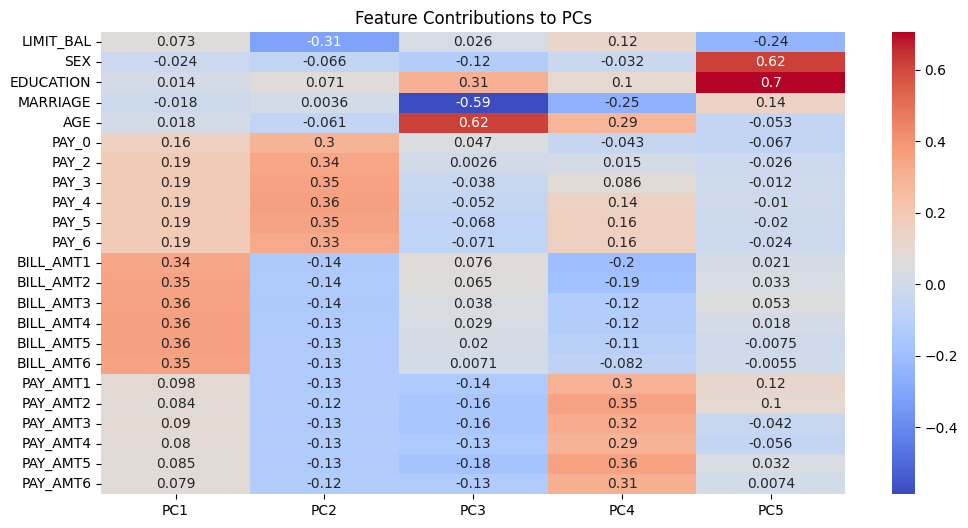

In [37]:
# Component loadings (how original features contribute to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=df_pca.columns,
    index=original_features  # Replace with your feature names
)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings.iloc[:, :5], annot=True, cmap='coolwarm')  # First 5 components
plt.title('Feature Contributions to PCs')
plt.show()

    - High PC1: Likely has large credit card bills.

    - High PC2: Frequently delays payments and has a low credit limit.

    - Low PC3: Younger, less educated, or married.

    - Low PC4: Pays smaller amounts monthly.

# SVM

In [38]:
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif, RFE

In [39]:
# Use SelectKBest with ANOVA F-test
selector = SelectKBest(score_func=f_classif, k='all')  # Consider all features
X_new = selector.fit_transform(X_train_scaled, y_train_balanced)

# Get the scores for each feature
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'ANOVA_Score': selector.scores_
}).sort_values(by='ANOVA_Score', ascending=False)  # Sort by score

# Print the ANOVA F-test scores
print("ANOVA F-test scores for features:")
print(feature_scores)

ANOVA F-test scores for features:
      Feature  ANOVA_Score
5       PAY_0  4658.209047
6       PAY_2  2759.248940
7       PAY_3  2219.598340
8       PAY_4  1912.018955
9       PAY_5  1764.021098
3    MARRIAGE  1626.054378
1         SEX  1557.659829
10      PAY_6  1542.038392
0   LIMIT_BAL  1202.537670
17   PAY_AMT1   458.689933
2   EDUCATION   378.840958
18   PAY_AMT2   310.744825
20   PAY_AMT4   305.913839
19   PAY_AMT3   282.666226
21   PAY_AMT5   280.954070
22   PAY_AMT6   268.047288
11  BILL_AMT1    21.376782
12  BILL_AMT2     7.437536
13  BILL_AMT3     6.500301
14  BILL_AMT4     2.753887
15  BILL_AMT5     1.798595
4         AGE     0.307142
16  BILL_AMT6     0.258014


In [40]:
# #Recursive Feature Elimination (RFE)
# svc = SVC(kernel="linear")
# selector = RFE(svc, n_features_to_select=5)
# selector.fit(X_train_scaled, y_train)
# print(selector.support_)

In [41]:
svm = SVC()

In [42]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix , classification_report

# Initialize Linear SVM
linear_svc = LinearSVC(random_state=42, max_iter=1000)

# Wrap with CalibratedClassifierCV for predict_proba
calibrated_svc = CalibratedClassifierCV(linear_svc, method='sigmoid', cv=3)

# Train
calibrated_svc.fit(X_train_scaled, y_train_balanced.values.ravel())

# Predictions
y_pred_linear = calibrated_svc.predict(X_test_scaled)
y_proba_linear = calibrated_svc.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_linear))
# print("ROC AUC:", roc_auc_score(y_test, y_proba_linear))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79      6978
           1       0.38      0.56      0.46      2012

    accuracy                           0.70      8990
   macro avg       0.62      0.65      0.62      8990
weighted avg       0.75      0.70      0.72      8990



In [43]:
# from sklearn.svm import SVC
# from sklearn.metrics import classification_report, confusion_matrix

# param_grid = {'C': [0.1, 1, 10, 100],
#               'gamma': [1, 0.1, 0.01, 0.001],
#               'kernel': ['rbf']}

# SVM_Model = SVC(gamma='auto')

# from sklearn.model_selection import RandomizedSearchCV
# rf_Grid = RandomizedSearchCV (estimator = SVM_Model, param_distributions = param_grid, cv = 3, verbose=2, n_jobs = 4)
# rf_Grid.fit(X,y)

In [44]:
# rf_Grid.best_params_

In [45]:
# print (f'Accuracy - : {rf_Grid.score(X,y):.3f}')


In [46]:
# y_pred = svm.predict(X_test_pca)

In [47]:
# print("SVM Accuracy after PCA:", round(accuracy_score(y_test, y_pred)*100, 2), "%")

In [48]:
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [49]:
svm_orig = SVC(kernel='rbf', C=10, gamma='scale',probability=True)
svm_orig.fit(X_train, y_train)
y_pred_orig = svm_orig.predict(X_test)

In [50]:
# --- Model 2: SVM on PCA Data ---
pca = PCA(n_components=15)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svm_pca = SVC(kernel='rbf', C=10, gamma='scale',probability=True)
svm_pca.fit(X_train_pca, y_train_balanced)
y_pred = svm_pca.predict(X_test_pca)


In [51]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
# Evaluation function
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    print(f"\n{name} Model:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Classification Report:")
    print(report)

# Evaluate both models
evaluate_model("SVM on Original Data", y_test, y_pred_orig)
evaluate_model("SVM on PCA Data", y_test, y_pred)


SVM on Original Data Model:
Accuracy: 0.7758
Recall: 0.0010
Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.87      6978
           1       0.25      0.00      0.00      2012

    accuracy                           0.78      8990
   macro avg       0.51      0.50      0.44      8990
weighted avg       0.66      0.78      0.68      8990


SVM on PCA Data Model:
Accuracy: 0.7402
Recall: 0.5671
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.83      6978
           1       0.44      0.57      0.49      2012

    accuracy                           0.74      8990
   macro avg       0.65      0.68      0.66      8990
weighted avg       0.77      0.74      0.75      8990



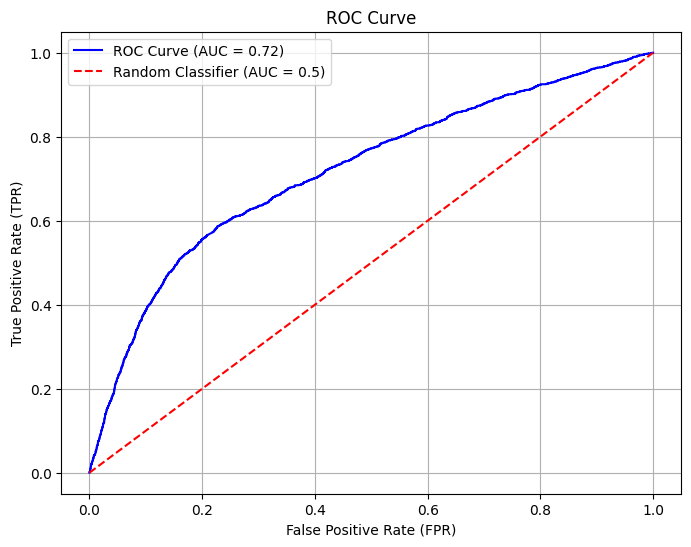

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Generate predicted probabilities for the positive class (class=1)
y_probs = svm_pca.predict_proba(X_test_pca)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

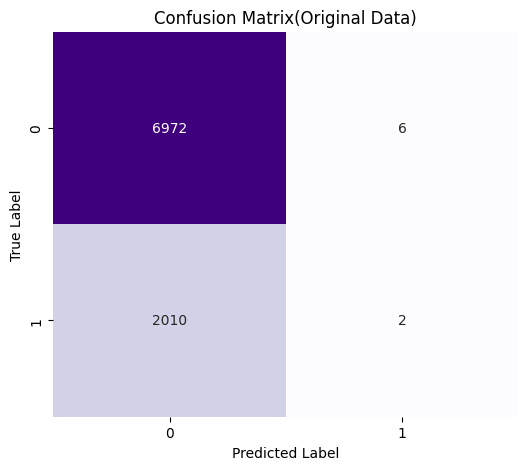

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_orig)
# Visualize the Confusion Matrix
def plot_confusion_matrix(conf_matrix):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix(Original Data)")
    plt.show()

plot_confusion_matrix(conf_matrix)

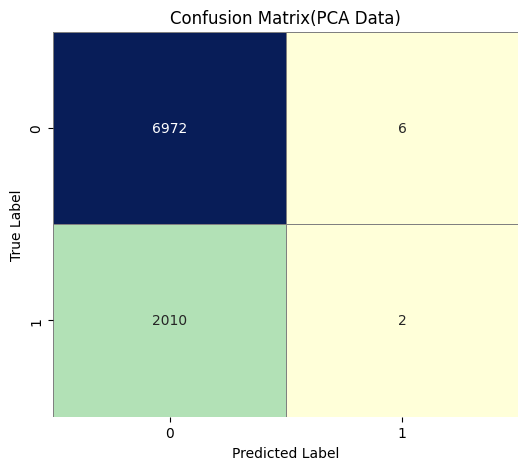

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_orig)

# Visualize the Confusion Matrix with updated color
def plot_confusion_matrix(conf_matrix):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5, linecolor='gray', cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix(PCA Data)")
    plt.show()

plot_confusion_matrix(conf_matrix)

**PCA Model (After Handling Imbalance)**

    Accuracy: 74.02%

        Accuracy decreases slightly but becomes more reliable.

    Recall (Class 1): 56.71%

        The model now detects 56.71% of Class 1 instances, a massive improvement.

    Confusion Matrix:

        Class 0: Correctly predicted 5,513/6,978 instances.

        Class 1: Correctly predicted 1,141/2,012 instances.

    Classification Report:

        Class 1: Precision = 44%, F1-score = 0.49.

        Macro Avg F1: 0.66 (better balance).

Key Insight:

    Handling imbalance (e.g., resampling or class weights) forced the model to prioritize Class 1, improving recall.

    Trade-Off: Lower precision for Class 1 (more false positives) and reduced accuracy.

Why the Changes Occurred

    Original Model:

        Focused on the majority class (Class 0) due to imbalance.

        Accuracy inflated by ignoring Class 1.

    PCA + Balanced Data:

        PCA reduced dimensionality, focusing on key features.

        Balancing ensured the model learned patterns for Class 1.

Key Takeaways

    Accuracy vs. Recall:

        Original model prioritized accuracy by ignoring Class 1.

        Balanced model sacrifices accuracy for critical Class 1 detection.

    Business Impact:

        Use the balanced model if detecting Class 1 is critical (e.g., fraud, medical diagnosis).

        If false positives are costly, adjust thresholds or use precision-focused techniques.

Final Note:
The improved recall for Class 1 (0.10% → 56.71%) is a significant win for imbalanced scenarios, even with slightly lower accuracy. Always align metrics with your use case’s priorities!

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Define pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale'))
])

# Fit pipeline on balanced training data
pipeline.fit(X_train_balanced, y_train_balanced)

# Predict
y_pred_pipeline = pipeline.predict(X_test)

# Evaluate
print("Pipeline Accuracy:", round(accuracy_score(y_test, y_pred_pipeline)*100, 2), "%")
print("Recall:", recall_score(y_test, y_pred_pca))


Pipeline Accuracy: 74.02 %
